In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/insurance_data.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst few rows:")
print(df.head())

# Derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Convert TransactionDate to datetime
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# 1. Overall Loss Ratio
overall_lr = df['LossRatio'].mean()
print(f"\nOverall Loss Ratio: {overall_lr:.3f}")

# 2. Loss Ratio by Province
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values()
print("\nLoss Ratio by Province:")
print(province_lr)

# 3. Loss Ratio by Gender
gender_lr = df.groupby('Gender')['LossRatio'].mean()
print("\nLoss Ratio by Gender:")
print(gender_lr)

# 4. Loss Ratio by VehicleType
vehicle_lr = df.groupby('VehicleType')['LossRatio'].mean().sort_values()
print("\nLoss Ratio by Vehicle Type:")
print(vehicle_lr)

# 5. Temporal trends (by month)
monthly_claims = df.groupby(df['TransactionDate'].dt.to_period('M'))['TotalClaims'].sum()
monthly_premiums = df.groupby(df['TransactionDate'].dt.to_period('M'))['TotalPremium'].sum()
monthly_loss_ratio = monthly_claims / monthly_premiums

print("\nMonthly Loss Ratio trend:")
print(monthly_loss_ratio.head())

# 6. Check for outliers in TotalClaims
print("\nTotalClaims Statistics:")
print(df['TotalClaims'].describe())

# Claims > 0 statistics
claims_data = df[df['TotalClaims'] > 0]
print(f"\nClaims data shape: {claims_data.shape}")
print(f"Percentage of policies with claims: {len(claims_data)/len(df)*100:.2f}%")
print(f"Average claim amount when claim occurs: {claims_data['TotalClaims'].mean():.2f}")
print(f"Max claim amount: {claims_data['TotalClaims'].max():.2f}")

# 7. Vehicle makes with highest claim amounts
if 'AutoMake' in df.columns:
    make_claims = df.groupby('AutoMake')['TotalClaims'].agg(['mean', 'sum', 'count']).sort_values('mean', ascending=False)
    print("\nTop 10 Vehicle Makes by Average Claim Amount:")
    print(make_claims.head(10))

Dataset shape: (10000, 21)

Column names:
['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate']

First few rows:
  CustomerID  Age  Gender     Province VehicleType  AnnualIncome  RiskScore  \
0  AC-100000   56    Male  Addis Ababa       Sedan        147270         61   
1  AC-100001   69  Female  Addis Ababa         SUV         74640         57   
2  AC-100002   46    Male       Oromia       Sedan         70555         42   
3  AC-100003   32  Female       Somali       Sedan         89398         63   
4  AC-100004   60  Female       Tigray         SUV         78475         69   

   AnnualPremium  Deductible  NCD  ...  Claimed  ClaimAmount  TotalPremium  \
0           2346         500   30  ...    False          0.0          2346   
1           2334   

QUESTION 1: LOSS RATIO ANALYSIS

1. Overall Portfolio Loss Ratio: 0.4428 (44.28%)

2. Loss Ratio by Province:
             LossRatio  TotalPremium  TotalClaims
Province                                         
Addis Ababa     0.4363       8907374    4653210.0
Amhara          0.3959       4928566    2353885.0
Oromia          0.4527       6069663    3261061.0
Somali          0.5235       2984984    1826593.0
Tigray          0.4386       1990692    1047136.0

3. Loss Ratio by Vehicle Type:
             LossRatio  TotalPremium  TotalClaims
VehicleType                                      
Hatchback       0.3708       4532134    1904235.0
Luxury          0.8037       4236839    3569207.0
SUV             0.4997       7256436    4090665.0
Sedan           0.3488       8855870    3577778.0

4. Loss Ratio by Gender:
        LossRatio  TotalPremium  TotalClaims
Gender                                      
Female     0.4474      12791141    6763030.0
Male       0.4379      12090138    6378855.0

Q

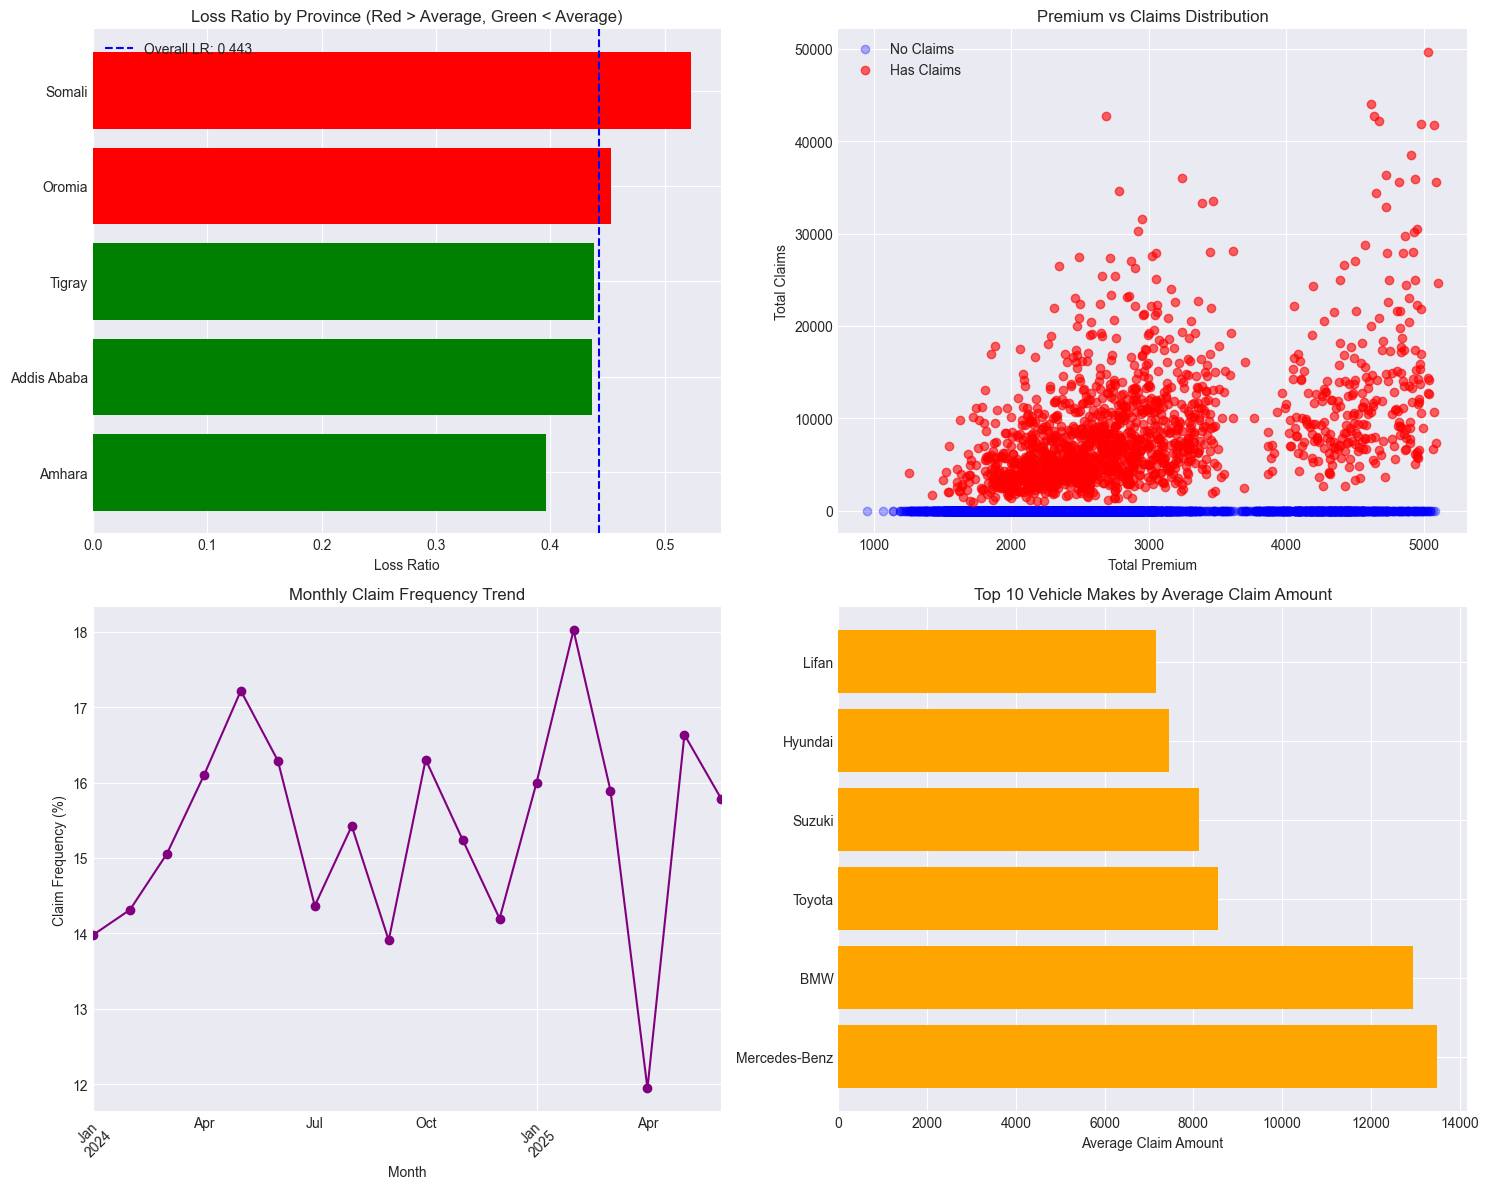

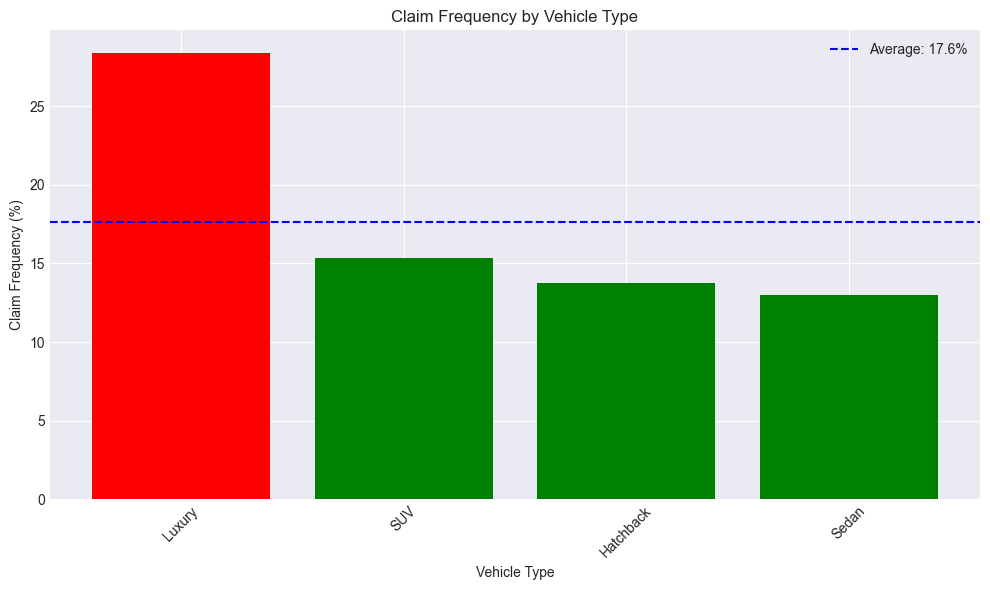

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/insurance_data.csv')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# ============================================
# QUESTION 1: Overall Loss Ratio & Variations
# ============================================
print("="*60)
print("QUESTION 1: LOSS RATIO ANALYSIS")
print("="*60)

# Overall Loss Ratio
overall_lr = df['LossRatio'].mean()
print(f"\n1. Overall Portfolio Loss Ratio: {overall_lr:.4f} ({overall_lr*100:.2f}%)")

# By Province
province_lr = df.groupby('Province').agg({
    'LossRatio': 'mean',
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).round(4)
print("\n2. Loss Ratio by Province:")
print(province_lr)

# By Vehicle Type
vehicle_lr = df.groupby('VehicleType').agg({
    'LossRatio': 'mean',
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).round(4)
print("\n3. Loss Ratio by Vehicle Type:")
print(vehicle_lr)

# By Gender
gender_lr = df.groupby('Gender').agg({
    'LossRatio': 'mean',
    'TotalPremium': 'sum',
    'TotalClaims': 'sum'
}).round(4)
print("\n4. Loss Ratio by Gender:")
print(gender_lr)

# ============================================
# QUESTION 2: Distribution of Financial Variables
# ============================================
print("\n" + "="*60)
print("QUESTION 2: FINANCIAL VARIABLE DISTRIBUTIONS")
print("="*60)

print("\nTotalPremium Statistics:")
print(df['TotalPremium'].describe())

print("\nTotalClaims Statistics:")
print(df['TotalClaims'].describe())

# Check for outliers using IQR
Q1 = df['TotalClaims'].quantile(0.25)
Q3 = df['TotalClaims'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalClaims'] > Q3 + 1.5*IQR) | (df['TotalClaims'] < Q1 - 1.5*IQR)]
print(f"\nOutliers in TotalClaims: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

# CustomValueEstimate outliers
Q1_cv = df['CustomValueEstimate'].quantile(0.25)
Q3_cv = df['CustomValueEstimate'].quantile(0.75)
IQR_cv = Q3_cv - Q1_cv
outliers_cv = df[(df['CustomValueEstimate'] > Q3_cv + 1.5*IQR_cv)]
print(f"Outliers in CustomValueEstimate: {len(outliers_cv)} rows ({len(outliers_cv)/len(df)*100:.2f}%)")

# ============================================
# QUESTION 3: Temporal Trends
# ============================================
print("\n" + "="*60)
print("QUESTION 3: TEMPORAL TRENDS")
print("="*60)

# Group by month
df['YearMonth'] = df['TransactionDate'].dt.to_period('M')
monthly_stats = df.groupby('YearMonth').agg({
    'TotalPremium': 'sum',
    'TotalClaims': 'sum',
    'LossRatio': 'mean'
})
print("\nMonthly Statistics:")
print(monthly_stats.head())

# Check if claim frequency changed over time
monthly_claim_freq = df.groupby('YearMonth').apply(
    lambda x: (x['TotalClaims'] > 0).sum() / len(x) * 100
)
print("\nMonthly Claim Frequency (%):")
print(monthly_claim_freq.head())

# ============================================
# QUESTION 4: Vehicle Makes with Highest/Lowest Claims
# ============================================
print("\n" + "="*60)
print("QUESTION 4: VEHICLE MAKE CLAIM ANALYSIS")
print("="*60)

# Only include rows with claims
claims_df = df[df['TotalClaims'] > 0]

# Highest claim amounts by make
make_claims = claims_df.groupby('AutoMake').agg({
    'TotalClaims': ['mean', 'sum', 'count']
}).round(2)
make_claims.columns = ['Avg_Claim', 'Total_Claims', 'Claim_Count']
make_claims = make_claims.sort_values('Avg_Claim', ascending=False)

print("\nTop 10 Vehicle Makes by Average Claim Amount:")
print(make_claims.head(10))

print("\nBottom 10 Vehicle Makes by Average Claim Amount:")
print(make_claims.tail(10))

# ============================================
# CREATE 3 INSIGHT-DRIVEN VISUALIZATIONS
# ============================================

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(15, 12))

# Plot 1: Loss Ratio by Province (Horizontal Bar Chart)
ax1 = fig.add_subplot(2, 2, 1)
province_lr_sorted = province_lr['LossRatio'].sort_values()
colors = ['red' if x > overall_lr else 'green' for x in province_lr_sorted]
ax1.barh(province_lr_sorted.index, province_lr_sorted.values, color=colors)
ax1.axvline(x=overall_lr, color='blue', linestyle='--', label=f'Overall LR: {overall_lr:.3f}')
ax1.set_xlabel('Loss Ratio')
ax1.set_title('Loss Ratio by Province (Red > Average, Green < Average)')
ax1.legend()

# Plot 2: Premium vs Claims Scatter (with claims>0 highlighted)
ax2 = fig.add_subplot(2, 2, 2)
no_claims = df[df['TotalClaims'] == 0]
has_claims = df[df['TotalClaims'] > 0]
ax2.scatter(no_claims['TotalPremium'], no_claims['TotalClaims'], 
            alpha=0.3, label='No Claims', color='blue')
ax2.scatter(has_claims['TotalPremium'], has_claims['TotalClaims'], 
            alpha=0.6, label='Has Claims', color='red')
ax2.set_xlabel('Total Premium')
ax2.set_ylabel('Total Claims')
ax2.set_title('Premium vs Claims Distribution')
ax2.legend()

# Plot 3: Monthly Claim Frequency Trend
ax3 = fig.add_subplot(2, 2, 3)
monthly_claim_freq.plot(kind='line', marker='o', ax=ax3, color='purple')
ax3.set_xlabel('Month')
ax3.set_ylabel('Claim Frequency (%)')
ax3.set_title('Monthly Claim Frequency Trend')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Top 10 Vehicle Makes by Average Claim
ax4 = fig.add_subplot(2, 2, 4)
top_makes = make_claims.head(10)
ax4.barh(top_makes.index, top_makes['Avg_Claim'], color='orange')
ax4.set_xlabel('Average Claim Amount')
ax4.set_title('Top 10 Vehicle Makes by Average Claim Amount')

plt.tight_layout()
plt.show()

# Additional Insight: Claim Frequency by Vehicle Type
plt.figure(figsize=(10, 6))
claim_freq_by_vehicle = df.groupby('VehicleType').apply(
    lambda x: (x['TotalClaims'] > 0).sum() / len(x) * 100
).sort_values(ascending=False)
colors = ['red' if x > claim_freq_by_vehicle.mean() else 'green' for x in claim_freq_by_vehicle]
plt.bar(claim_freq_by_vehicle.index, claim_freq_by_vehicle.values, color=colors)
plt.axhline(y=claim_freq_by_vehicle.mean(), color='blue', linestyle='--', 
            label=f'Average: {claim_freq_by_vehicle.mean():.1f}%')
plt.xlabel('Vehicle Type')
plt.ylabel('Claim Frequency (%)')
plt.title('Claim Frequency by Vehicle Type')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import os

# Create reports directory if it doesn't exist
os.makedirs('../reports', exist_ok=True)
print("Reports folder created!")
# After creating Figure 1 (Distribution)
plt.savefig('../reports/figure1_distribution.png', dpi=300, bbox_inches='tight')

# After creating Figure 2 (Premium vs Claims Scatter)
plt.savefig('../reports/figure2_scatter.png', dpi=300, bbox_inches='tight')

# After creating Figure 3 (Loss Ratio by Province)
plt.savefig('../reports/figure3_loss_ratio_province.png', dpi=300, bbox_inches='tight')

# After creating Figure 4 (Claim Amount by Vehicle Make)
plt.savefig('../reports/figure4_claim_by_make.png', dpi=300, bbox_inches='tight')

Reports folder created!


<Figure size 640x480 with 0 Axes>

In [15]:
import os

# Show current working directory
print("Current working directory:", os.getcwd())

# List files in current directory
print("\nFiles in current directory:")
print(os.listdir('.'))

# Check if data folder exists here
print("\nDoes 'data' folder exist here?", os.path.exists('data'))

# If data exists, what's in it?
if os.path.exists('data'):
    print("\nContents of data folder:")
    print(os.listdir('data'))

# Check one level up
parent_dir = os.path.dirname(os.getcwd())
print(f"\nParent directory: {parent_dir}")
print(f"Does data exist in parent?", os.path.exists(os.path.join(parent_dir, 'data')))

Current working directory: c:\Users\dell\Documents\GitHub\insurance-risk-analytics\notebooks

Files in current directory:
['01_eda.ipynb']

Does 'data' folder exist here? False

Parent directory: c:\Users\dell\Documents\GitHub\insurance-risk-analytics
Does data exist in parent? True


In [21]:
import os

# List contents of data folder
print("Contents of data folder:")
print(os.listdir('data'))

Contents of data folder:
['insurance_data.csv.dvc', 'insurance_data_clean.csv']


In [24]:
import os

# Where is your notebook running from?
print("Current working directory:", os.getcwd())

# What files are in this directory?
print("\nFiles in current directory:")
print(os.listdir('.'))

# Check if data folder exists here
print("\nDoes 'data' folder exist here?", os.path.exists('data'))

# Check one level up
print("\nChecking parent directory:")
parent = os.path.dirname(os.getcwd())
print("Parent directory:", parent)
print("Files in parent:", os.listdir(parent) if os.path.exists(parent) else "Cannot access")

Current working directory: c:\Users\dell\Documents\GitHub\insurance-risk-analytics

Files in current directory:
['.dvc', '.dvcignore', '.git', '.github', '.gitignore', 'data', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'scripts', 'src', 'tests']

Does 'data' folder exist here? True

Checking parent directory:
Parent directory: c:\Users\dell\Documents\GitHub
Files in parent: ['Acadamia-connect', 'AgriPay_Letter_flutter_GDG_Hackathon', 'campus-menu-compass-IP2', 'climate-challenge-week0', 'CodeAlpha_flashcardquizapp', 'dr-senait-frontend', 'Evenet-Managment-System', 'facebook', 'fintech-review-analytics', 'fluent internship task1', 'fluentian internship task1', 'infnova-internship', 'insurance-risk-analytics', 'nexo', 'nova-sentiment-stock-analysis', 'portfolio', 'sample-testing', 'sample_eccomerce_testing', 'schoolinspectionsystem', 'Smart-Restaurant-Ordering-System', 'Tova']


✓ Data loaded successfully!
Shape: (9900, 23)

First 3 rows:
  CustomerID  Age  Gender     Province VehicleType  AnnualIncome  RiskScore  \
0  AC-100000   56    Male  Addis Ababa       Sedan        147270         61   
1  AC-100001   69  Female  Addis Ababa         SUV         74640         57   
2  AC-100002   46    Male       Oromia       Sedan         70555         42   

   AnnualPremium  Deductible  NCD  ...  TotalPremium  TotalClaims  \
0           2346         500   30  ...          2346          0.0   
1           2334         500    0  ...          2334       9883.0   
2           1697         250   20  ...          1697          0.0   

                  CoverType  AutoMake  VehicleModel CustomValueEstimate  \
0             Comprehensive     Lifan           620               32238   
1             Comprehensive    Suzuki  Grand Vitara               52510   
2  Third Party Fire & Theft     Lifan           620               26523   

  ZipCode TransactionDate  LossRatio  Margin

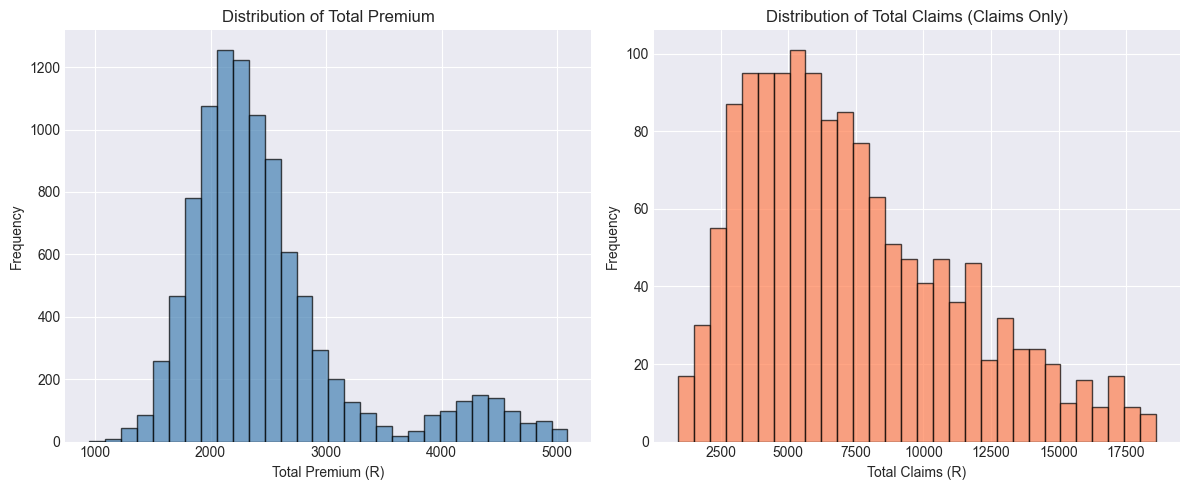

✓ Figure 1 saved


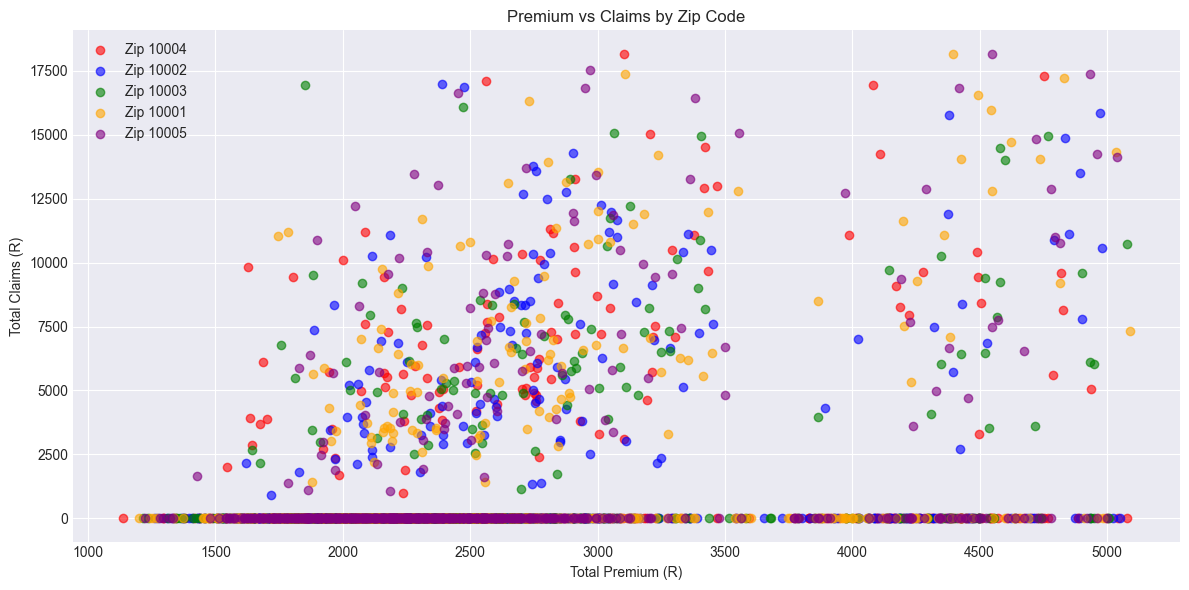

✓ Figure 2 saved


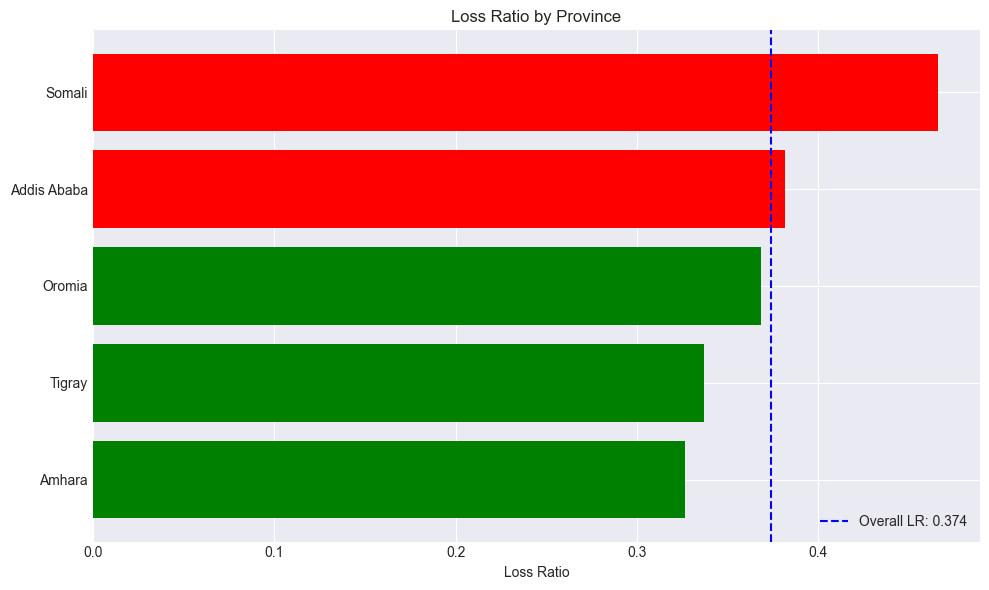

✓ Figure 3 saved


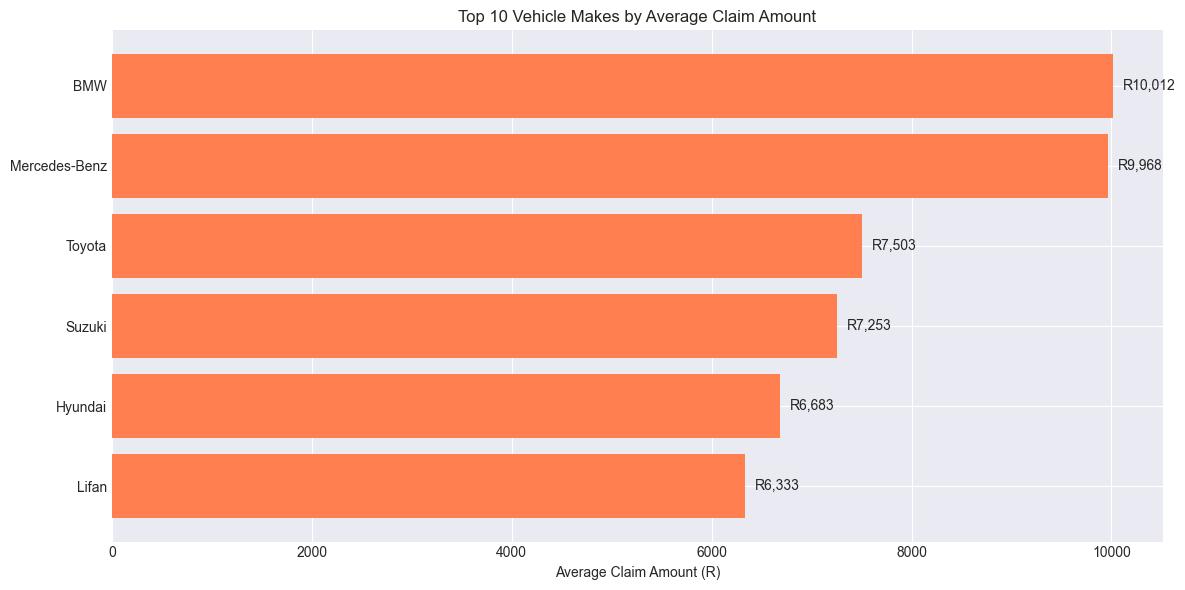

✓ Figure 4 saved

SUCCESS! All 4 figures saved to 'reports' folder!
Files saved:
  - reports/figure1_distribution.png
  - reports/figure2_scatter.png
  - reports/figure3_loss_ratio_province.png
  - reports/figure4_claim_by_make.png


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load the cleaned data (this file exists)
df = pd.read_csv('data/insurance_data_clean.csv')

print("✓ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:\n{df.head(3)}")
print(f"\nColumns: {df.columns.tolist()}")

# Create reports folder
os.makedirs('reports', exist_ok=True)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# ============================================
# FIGURE 1: Distribution of Total Premium and Total Claims
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['TotalPremium'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Total Premium (R)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Total Premium')

claims_nonzero = df[df['TotalClaims'] > 0]['TotalClaims']
if len(claims_nonzero) > 0:
    axes[1].hist(claims_nonzero, bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[1].set_xlabel('Total Claims (R)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Total Claims (Claims Only)')
else:
    axes[1].text(0.5, 0.5, 'No claims data', transform=axes[1].transAxes, ha='center')

plt.tight_layout()
plt.savefig('reports/figure1_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 1 saved")

# ============================================
# FIGURE 2: Scatter Plot - Premium vs Claims by Zip Code
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

top_zips = df['ZipCode'].value_counts().head(5).index.tolist()
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, zip_code in enumerate(top_zips):
    subset = df[df['ZipCode'] == zip_code]
    ax.scatter(subset['TotalPremium'], subset['TotalClaims'], 
               alpha=0.6, label=f'Zip {zip_code}', color=colors[i % len(colors)])

ax.set_xlabel('Total Premium (R)')
ax.set_ylabel('Total Claims (R)')
ax.set_title('Premium vs Claims by Zip Code')
ax.legend()

plt.tight_layout()
plt.savefig('reports/figure2_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved")

# ============================================
# FIGURE 3: Loss Ratio by Province
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate loss ratio
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

province_lr = df.groupby('Province')['LossRatio'].mean().sort_values()
overall_lr = df['LossRatio'].mean()

colors = ['red' if x > overall_lr else 'green' for x in province_lr.values]
ax.barh(province_lr.index, province_lr.values, color=colors)
ax.axvline(x=overall_lr, color='blue', linestyle='--', label=f'Overall LR: {overall_lr:.3f}')
ax.set_xlabel('Loss Ratio')
ax.set_title('Loss Ratio by Province')
ax.legend()

plt.tight_layout()
plt.savefig('reports/figure3_loss_ratio_province.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 3 saved")

# ============================================
# FIGURE 4: Average Claim Amount by Vehicle Make
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

claims_df = df[df['TotalClaims'] > 0]
if len(claims_df) > 0:
    make_claims = claims_df.groupby('AutoMake')['TotalClaims'].mean().sort_values(ascending=False).head(10)
    ax.barh(make_claims.index, make_claims.values, color='coral')
    ax.set_xlabel('Average Claim Amount (R)')
    ax.set_title('Top 10 Vehicle Makes by Average Claim Amount')
    ax.invert_yaxis()
    
    # Add value labels
    for i, (make, value) in enumerate(make_claims.items()):
        ax.text(value + 100, i, f'R{value:,.0f}', va='center')
else:
    ax.text(0.5, 0.5, 'No claims data available', transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig('reports/figure4_claim_by_make.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 4 saved")

print("\n" + "="*50)
print("SUCCESS! All 4 figures saved to 'reports' folder!")
print("Files saved:")
print("  - reports/figure1_distribution.png")
print("  - reports/figure2_scatter.png")
print("  - reports/figure3_loss_ratio_province.png")
print("  - reports/figure4_claim_by_make.png")
print("="*50)